# Hotel Analysis

## Dataset Path: https://github.com/swapnilsaurav/Dataset/blob/master/hotel_bookings.csv

# Data Preparation And Cleaning
### Cleaning the data before analysis

In [288]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding dataset

In [289]:
df = pd.read_csv(r"hotel_bookings.csv")
pd.set_option('display.max_columns', 33)
df.head(5)

,id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,Resort Hotel,0.0,342.0,2015,July,27.0,1.0,0.0,0.0,2.0,0.0,0.0,BB,PRT,Direct,Direct,0.0,0.0,0.0,C,C,3.0,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,01-07-2015
1,2,Resort Hotel,0.0,737.0,2015,July,27.0,1.0,0.0,0.0,2.0,0.0,0.0,BB,PRT,Direct,Direct,0.0,0.0,0.0,C,C,4.0,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,10.0,Check-Out,01-07-2015
2,3,Resort Hotel,0.0,7.0,2015,July,27.0,1.0,0.0,1.0,1.0,0.0,0.0,BB,GBR,Direct,Direct,0.0,0.0,0.0,A,C,0.0,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015
3,4,Resort Hotel,0.0,13.0,2015,July,27.0,1.0,0.0,1.0,1.0,0.0,0.0,BB,GBR,Corporate,Corporate,0.0,0.0,0.0,A,A,0.0,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015
4,5,Resort Hotel,0.0,14.0,2015,July,27.0,1.0,0.0,2.0,2.0,0.0,0.0,BB,GBR,Online TA,TA/TO,0.0,0.0,0.0,A,A,0.0,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,03-07-2015


In [290]:
df.describe(include = 'all')

,id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390.000000,119390,119380.000000,119380.000000,119390.000000,119390,119376.000000,119376.000000,119376.000000,119376.000000,119376.000000,116929.000000,105873.000000,105687,118888,119376,119376,119376.000000,119376.000000,119376.000000,119376,119376,119376.000000,109548,103037.000000,6797.000000,119376.000000,119376,119376.000000,119376.00000,119376.000000,119376,119376
unique,NaN,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,177,8,5,NaN,NaN,NaN,10,12,NaN,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,NaN,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,TA/TO,NaN,NaN,NaN,A,A,NaN,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,21-10-2015
freq,NaN,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82604,48582,56467,97859,NaN,NaN,NaN,85990,74053,NaN,94800,NaN,NaN,NaN,89599,NaN,NaN,NaN,75153,1461
mean,59695.500000,NaN,0.370447,104.014265,2016.156554,NaN,27.165075,15.799390,0.927607,2.500352,1.856378,0.102866,0.007452,NaN,NaN,NaN,NaN,0.031916,0.087128,0.137113,NaN,NaN,0.221133,NaN,86.675223,189.266735,2.321421,NaN,101.829793,0.06250,0.602684,NaN,NaN
std,34465.068657,NaN,0.482927,106.866472,0.707476,NaN,13.605933,8.780703,0.998665,1.908337,0.579269,0.395552,0.095675,NaN,NaN,NaN,NaN,0.175777,0.844385,1.497524,NaN,NaN,0.652332,NaN,110.768871,131.655015,17.595735,NaN,50.534788,0.24526,3.393265,NaN,NaN
min,1.000000,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.00000,-99.000000,NaN,NaN
25%,29848.250000,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,9.000000,62.000000,0.000000,NaN,69.280000,0.00000,0.000000,NaN,NaN
50%,59695.500000,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,14.000000,179.000000,0.000000,NaN,94.510000,0.00000,0.000000,NaN,NaN
75%,89542.750000,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.00000,1.000000,NaN,NaN


In [291]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              119390 non-null  int64  
 1   hotel                           119390 non-null  str    
 2   is_canceled                     119380 non-null  float64
 3   lead_time                       119380 non-null  float64
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  str    
 6   arrival_date_week_number        119376 non-null  float64
 7   arrival_date_day_of_month       119376 non-null  float64
 8   stays_in_weekend_nights         119376 non-null  float64
 9   stays_in_week_nights            119376 non-null  float64
 10  adults                          119376 non-null  float64
 11  children                        116929 non-null  float64
 12  babies                     

(119390, 33)

### Missing Value Percentage

In [292]:
missing = df.isnull().sum()
null_percent = missing/len(df)* 100
print(null_percent.map(lambda x : f"{x:.2f}%"))

id                                 0.00%
hotel                              0.00%
is_canceled                        0.01%
lead_time                          0.01%
arrival_date_year                  0.00%
arrival_date_month                 0.00%
arrival_date_week_number           0.01%
arrival_date_day_of_month          0.01%
stays_in_weekend_nights            0.01%
stays_in_week_nights               0.01%
adults                             0.01%
children                           2.06%
babies                            11.32%
meal                              11.48%
country                            0.42%
market_segment                     0.01%
distribution_channel               0.01%
is_repeated_guest                  0.01%
previous_cancellations             0.01%
previous_bookings_not_canceled     0.01%
reserved_room_type                 0.01%
assigned_room_type                 0.01%
booking_changes                    0.01%
deposit_type                       8.24%
agent           

### Making Copy Before Cleaning The Dataset

In [293]:
df2 = df.copy()
df2.head(5)

,id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,Resort Hotel,0.0,342.0,2015,July,27.0,1.0,0.0,0.0,2.0,0.0,0.0,BB,PRT,Direct,Direct,0.0,0.0,0.0,C,C,3.0,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,01-07-2015
1,2,Resort Hotel,0.0,737.0,2015,July,27.0,1.0,0.0,0.0,2.0,0.0,0.0,BB,PRT,Direct,Direct,0.0,0.0,0.0,C,C,4.0,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,10.0,Check-Out,01-07-2015
2,3,Resort Hotel,0.0,7.0,2015,July,27.0,1.0,0.0,1.0,1.0,0.0,0.0,BB,GBR,Direct,Direct,0.0,0.0,0.0,A,C,0.0,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015
3,4,Resort Hotel,0.0,13.0,2015,July,27.0,1.0,0.0,1.0,1.0,0.0,0.0,BB,GBR,Corporate,Corporate,0.0,0.0,0.0,A,A,0.0,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015
4,5,Resort Hotel,0.0,14.0,2015,July,27.0,1.0,0.0,2.0,2.0,0.0,0.0,BB,GBR,Online TA,TA/TO,0.0,0.0,0.0,A,A,0.0,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,03-07-2015


### Data Cleaning

In [294]:
df2.drop(['company'],axis = 1, inplace =True)

In [295]:
df2['babies'] = df2['babies'].fillna(0)
df2['children'] = df2['children'].fillna(0)

In [296]:
df2.rename(columns = {'agent' : 'agent_id'}, inplace =True)  

In [297]:
for column in df2.columns:
    if df2[column].isnull().sum() >0:
        
        if pd.api.types.is_numeric_dtype(df2[column]):
            df2[column] = df2[column].fillna(df2[column].mean())
            
        else:
            df2[column] = df2[column].fillna(df2[column].mode()[0])

### Removed All The Null Values

In [298]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              119390 non-null  int64  
 1   hotel                           119390 non-null  str    
 2   is_canceled                     119390 non-null  float64
 3   lead_time                       119390 non-null  float64
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  str    
 6   arrival_date_week_number        119390 non-null  float64
 7   arrival_date_day_of_month       119390 non-null  float64
 8   stays_in_weekend_nights         119390 non-null  float64
 9   stays_in_week_nights            119390 non-null  float64
 10  adults                          119390 non-null  float64
 11  children                        119390 non-null  float64
 12  babies                     

### Adding New Columns for Analysis

In [299]:
df2['arrival_date_day_of_month'] = df2['arrival_date_day_of_month'].astype(int)

In [300]:
df2['arrival_date'] =pd.to_datetime(df2['arrival_date_year'].astype(str)+ 
                                    '-' + df2['arrival_date_month'].astype(str)+
                                    '-'+ df2['arrival_date_day_of_month'].astype(str),format = '%Y-%B-%d',errors = 'coerce')

In [301]:
df2.head(5)

,id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,1,Resort Hotel,0.0,342.0,2015,July,27.0,1,0.0,0.0,2.0,0.0,0.0,BB,PRT,Direct,Direct,0.0,0.0,0.0,C,C,3.0,No Deposit,86.675223,0.0,Transient,0.0,0.0,0.0,Check-Out,01-07-2015,2015-07-01
1,2,Resort Hotel,0.0,737.0,2015,July,27.0,1,0.0,0.0,2.0,0.0,0.0,BB,PRT,Direct,Direct,0.0,0.0,0.0,C,C,4.0,No Deposit,86.675223,0.0,Transient,0.0,0.0,10.0,Check-Out,01-07-2015,2015-07-01
2,3,Resort Hotel,0.0,7.0,2015,July,27.0,1,0.0,1.0,1.0,0.0,0.0,BB,GBR,Direct,Direct,0.0,0.0,0.0,A,C,0.0,No Deposit,86.675223,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015,2015-07-01
3,4,Resort Hotel,0.0,13.0,2015,July,27.0,1,0.0,1.0,1.0,0.0,0.0,BB,GBR,Corporate,Corporate,0.0,0.0,0.0,A,A,0.0,No Deposit,304.000000,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015,2015-07-01
4,5,Resort Hotel,0.0,14.0,2015,July,27.0,1,0.0,2.0,2.0,0.0,0.0,BB,GBR,Online TA,TA/TO,0.0,0.0,0.0,A,A,0.0,No Deposit,240.000000,0.0,Transient,98.0,0.0,1.0,Check-Out,03-07-2015,2015-07-01


### Changing The Data Types 

In [302]:
df2['adults'] = df2['adults'].astype(int)

In [303]:
df2['children'] = df2['children'].astype(int)

In [304]:
df2['babies'] = df2['babies'].astype(int)

In [305]:
df2['is_repeated_guest'] = df2['is_repeated_guest'].astype(int)

In [306]:
df2['lead_time'] = df2['lead_time'].astype(int)

In [307]:
df2['stays_in_weekend_nights'] = df2['stays_in_weekend_nights'].astype(int)

In [308]:
df2['arrival_date_week_number'] = df2['arrival_date_week_number'].astype(int)

In [309]:
df2['required_car_parking_spaces'] = df2['required_car_parking_spaces'].astype(int)

In [310]:
df2['is_canceled'] = df2['is_canceled'].astype(int)
df2['days_in_waiting_list'] = df2['days_in_waiting_list'].astype(int) 

In [311]:
df2['total_of_special_requests'] = df2['total_of_special_requests'].astype(int)

In [312]:
df2['booking_changes'] = df2['booking_changes'].astype(int)

In [313]:
df2['agent_id'] = df2['agent_id'].astype(int)

In [314]:
df2['previous_bookings_not_canceled'] = df2['previous_bookings_not_canceled'].astype(int)

In [315]:
df2['stays_in_week_nights'] = df2['stays_in_week_nights'].astype(int)

### Creating Column for Total Nights Stayed

In [316]:
df2['total_days_stayed'] = df2['stays_in_weekend_nights'] + df2['stays_in_week_nights']

In [317]:
df2.drop(['stays_in_week_nights'],axis = 1, inplace = True)

In [318]:
df2.drop(['stays_in_weekend_nights'],axis = 1, inplace = True)

In [319]:
df2['reservation_status_date'] = pd.to_datetime(df2['reservation_status_date'],format = '%d-%m-%Y')

In [320]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              119390 non-null  int64         
 1   hotel                           119390 non-null  str           
 2   is_canceled                     119390 non-null  int64         
 3   lead_time                       119390 non-null  int64         
 4   arrival_date_year               119390 non-null  int64         
 5   arrival_date_month              119390 non-null  str           
 6   arrival_date_week_number        119390 non-null  int64         
 7   arrival_date_day_of_month       119390 non-null  int64         
 8   adults                          119390 non-null  int64         
 9   children                        119390 non-null  int64         
 10  babies                          119390 non-null  int64         
 11

In [321]:
df2.drop(['arrival_date_month'],axis = 1, inplace =True)
df2.drop(['arrival_date_day_of_month'],axis = 1, inplace =True)
df2.drop(['arrival_date_year'],axis = 1, inplace =True)

In [322]:
df2['is_repeated_guest'].value_counts()

is_repeated_guest
0    115580
1      3810
Name: count, dtype: int64

In [323]:
df2['previous_cancellations'].value_counts()

previous_cancellations
0.000000     112892
1.000000       6051
2.000000        116
3.000000         65
24.000000        48
11.000000        35
4.000000         31
26.000000        26
25.000000        25
6.000000         22
19.000000        19
5.000000         19
0.087128         14
14.000000        14
13.000000        12
21.000000         1
Name: count, dtype: int64

### Value 0.087128 appears 14 times in dataset 
checking for duplicate values

In [324]:
df2[df2['previous_cancellations']%1!=0]['previous_cancellations']

160    0.087128
161    0.087128
162    0.087128
163    0.087128
164    0.087128
165    0.087128
166    0.087128
167    0.087128
168    0.087128
169    0.087128
170    0.087128
171    0.087128
172    0.087128
173    0.087128
Name: previous_cancellations, dtype: float64

In [325]:
df2['previous_cancellations'] = df2['previous_cancellations'].astype(int)


In [326]:
df2.loc[160:168]

,id,hotel,is_canceled,lead_time,arrival_date_week_number,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_days_stayed
160,161,Resort Hotel,0,104,27,1,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,86,2,Transient,101.829793,0,0,Check-Out,2015-10-21,2015-07-15,2
161,162,Resort Hotel,0,104,27,1,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,86,2,Transient,101.829793,0,0,Check-Out,2015-10-21,2015-07-15,2
162,163,Resort Hotel,0,104,27,1,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,86,2,Transient,101.829793,0,0,Check-Out,2015-10-21,2015-07-15,2
163,164,Resort Hotel,0,104,27,1,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,86,2,Transient,101.829793,0,0,Check-Out,2015-10-21,2015-07-15,2
164,165,Resort Hotel,0,104,27,1,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,86,2,Transient,101.829793,0,0,Check-Out,2015-10-21,2015-07-15,2
165,166,Resort Hotel,0,104,27,1,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,86,2,Transient,101.829793,0,0,Check-Out,2015-10-21,2015-07-15,2
166,167,Resort Hotel,0,104,27,1,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,86,2,Transient,101.829793,0,0,Check-Out,2015-10-21,2015-07-15,2
167,168,Resort Hotel,0,104,27,1,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,86,2,Transient,101.829793,0,0,Check-Out,2015-10-21,2015-07-15,2
168,169,Resort Hotel,0,104,27,1,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,86,2,Transient,101.829793,0,0,Check-Out,2015-10-21,2015-07-15,2


### Check for duplicates
As there are many identical rows (exclude the id and check)

In [327]:
df2[df2.drop(columns = ['id']).duplicated(keep = False)]

,id,hotel,is_canceled,lead_time,arrival_date_week_number,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_days_stayed
4,5,Resort Hotel,0,14,27,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,Transient,98.00,0,1,Check-Out,2015-07-03,2015-07-01,2
5,6,Resort Hotel,0,14,27,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,Transient,98.00,0,1,Check-Out,2015-07-03,2015-07-01,2
21,22,Resort Hotel,0,72,27,2,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250,0,Transient,84.67,0,1,Check-Out,2015-07-07,2015-07-01,6
22,23,Resort Hotel,0,72,27,2,0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250,0,Transient,84.67,0,1,Check-Out,2015-07-07,2015-07-01,6
39,40,Resort Hotel,0,70,27,2,0,0,BB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250,0,Transient,137.00,0,-99,Check-Out,2015-07-07,2015-07-02,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119352,119353,City Hotel,0,63,35,3,0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03,2017-08-31,3
119353,119354,City Hotel,0,63,35,3,0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03,2017-08-31,3
119354,119355,City Hotel,0,63,35,3,0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03,2017-08-31,3
119372,119373,City Hotel,0,175,35,1,0,0,BB,NLD,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,42,0,Transient,82.35,0,1,Check-Out,2017-09-04,2017-08-31,4


### Removing The Duplicates Keeping The First Value

In [328]:
print(f"Duplicate rows: {df2.drop(columns=['id']).duplicated().sum()}")
df2 = df2.drop_duplicates(subset=df2.columns.difference(['id']), keep='first')
print(f"Shape after dedup: {df2.shape}")

Duplicate rows: 32012
Shape after dedup: (87378, 29)


In [329]:
df2.head(5)

,id,hotel,is_canceled,lead_time,arrival_date_week_number,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_days_stayed
0,1,Resort Hotel,0,342,27,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,86,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,0
1,2,Resort Hotel,0,737,27,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,86,0,Transient,0.0,0,10,Check-Out,2015-07-01,2015-07-01,0
2,3,Resort Hotel,0,7,27,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,86,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1
3,4,Resort Hotel,0,13,27,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,1
4,5,Resort Hotel,0,14,27,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2


### checking For Invalid Sentinal Values

In [330]:
df2['arrival_date_week_number'].value_counts().sort_index()

arrival_date_week_number
1      862
2      945
3     1049
4     1124
5     1101
6     1295
7     1629
8     1523
9     1579
10    1630
11    1657
12    1572
13    1817
14    1693
15    1989
16    1738
17    1881
18    2089
19    1813
20    1843
21    2043
22    1753
23    1872
24    1746
25    1787
26    1740
27    2171
28    2329
29    2197
30    2335
31    2286
32    2450
33    2792
34    2491
35    2106
36    1626
37    1474
38    1634
39    1591
40    1429
41    1663
42    1447
43    1606
44    1548
45    1314
46    1141
47    1289
48    1199
49    1169
50    1053
51     785
52    1063
53    1420
Name: count, dtype: int64

In [331]:
df2['previous_bookings_not_canceled'].value_counts()

previous_bookings_not_canceled
0     83833
1      1482
2       580
3       331
4       228
      ...  
68        1
69        1
70        1
71        1
72        1
Name: count, Length: 73, dtype: int64

In [332]:
df2['booking_changes'].value_counts().sort_index()

booking_changes
0     71477
1     10901
2      3508
3       875
4       356
5       116
6        59
7        31
8        17
9         8
10        6
11        2
12        2
13        5
14        5
15        3
16        2
17        2
18        1
20        1
21        1
Name: count, dtype: int64

In [333]:
df2['agent_id'].value_counts().sort_index()

agent_id
1      1232
2       129
3       363
4        18
5       216
       ... 
510       1
526      10
527      25
531      60
535       3
Name: count, Length: 333, dtype: int64

In [334]:
df2['required_car_parking_spaces'].value_counts()

required_car_parking_spaces
0    80068
1     7277
2       28
3        3
8        2
Name: count, dtype: int64

In [335]:
df2['total_of_special_requests'].value_counts()

total_of_special_requests
 0      43836
 1      28982
 2      11785
 3       2316
 4        320
 120       63
-99        38
 5         36
 10         1
-8          1
Name: count, dtype: int64

#### Special Requests cannot be negetive

In [336]:
df2[df2['total_of_special_requests']<0 ]

,id,hotel,is_canceled,lead_time,arrival_date_week_number,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_days_stayed
33,34,Resort Hotel,0,69,27,2,0,0,BB,IRL,Offline TA/TO,TA/TO,0,0,0,A,C,0,No Deposit,175,0,Transient,65.50,0,-8,Check-Out,2015-07-08,2015-07-02,6
36,37,Resort Hotel,0,15,27,2,0,0,BB,ESP,Online TA,TA/TO,0,0,0,A,C,0,No Deposit,240,0,Transient,98.00,0,-99,Check-Out,2015-07-06,2015-07-02,4
37,38,Resort Hotel,0,36,27,3,0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,241,0,Transient,108.80,0,-99,Check-Out,2015-07-06,2015-07-02,4
38,39,Resort Hotel,1,43,27,3,0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,241,0,Transient,108.80,0,-99,Canceled,2015-05-23,2015-07-02,4
39,40,Resort Hotel,0,70,27,2,0,0,BB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250,0,Transient,137.00,0,-99,Check-Out,2015-07-07,2015-07-02,5
40,41,Resort Hotel,1,45,27,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,G,G,0,No Deposit,241,0,Transient,117.81,0,-99,Canceled,2015-05-18,2015-07-02,5
41,42,Resort Hotel,0,45,27,2,0,0,BB,IRL,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,8,0,Contract,79.50,0,-99,Check-Out,2015-07-07,2015-07-02,5
42,43,Resort Hotel,0,16,27,2,0,0,BB,ESP,Direct,Direct,0,0,0,F,F,0,No Deposit,86,0,Transient,123.00,0,-99,Check-Out,2015-07-07,2015-07-02,5
44,45,Resort Hotel,0,107,27,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,Transient,110.70,0,-99,Check-Out,2015-07-09,2015-07-02,7
45,46,Resort Hotel,1,47,27,2,2,0,BB,PRT,Online TA,TA/TO,0,0,0,G,G,0,No Deposit,240,0,Transient,153.00,0,-99,Canceled,2015-06-02,2015-07-02,7


In [337]:
df2.loc[df2['total_of_special_requests'] <0 ,'total_of_special_requests'] = 0

In [338]:
df2['total_of_special_requests'].value_counts()

total_of_special_requests
0      43875
1      28982
2      11785
3       2316
4        320
120       63
5         36
10         1
Name: count, dtype: int64

In [339]:
df2[df2['total_of_special_requests'] == 120]

,id,hotel,is_canceled,lead_time,arrival_date_week_number,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_days_stayed
92,93,Resort Hotel,0,9,27,2,0,0,BB,USA,Online TA,TA/TO,0,0,0,C,C,0,No Deposit,241,0,Transient,94.71,0,120,Check-Out,2015-07-04,2015-07-03,1
93,94,Resort Hotel,0,109,27,2,0,0,BB,BEL,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,Transient,123.00,0,120,Check-Out,2015-07-04,2015-07-03,1
94,95,Resort Hotel,1,109,27,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,Transient,123.00,0,120,Canceled,2015-05-26,2015-07-03,2
95,96,Resort Hotel,1,72,27,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,Transient,73.80,0,120,Canceled,2015-06-29,2015-07-03,2
96,97,Resort Hotel,1,63,27,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,F,F,0,No Deposit,242,0,Transient,117.00,0,120,Canceled,2015-05-13,2015-07-03,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,152,Resort Hotel,0,29,28,2,0,0,BB,IRL,Online TA,TA/TO,0,0,0,F,F,0,No Deposit,241,0,Transient,97.29,0,120,Check-Out,2015-07-12,2015-07-05,7
152,153,Resort Hotel,1,101,28,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,Transient,114.00,0,120,Canceled,2015-03-30,2015-07-05,7
153,154,Resort Hotel,0,27,28,2,0,0,BB,ESP,Offline TA/TO,TA/TO,0,0,0,E,E,0,No Deposit,175,0,Transient,98.40,0,120,Check-Out,2015-07-12,2015-07-05,7
154,155,Resort Hotel,0,8,28,2,2,0,BB,CHE,Online TA,TA/TO,0,0,0,H,H,1,No Deposit,240,0,Transient,175.00,1,120,Check-Out,2015-07-14,2015-07-05,9


In [340]:
df2= df2.drop(df2[df2['total_of_special_requests']==120].index)

In [341]:
df2['total_of_special_requests'].value_counts()

total_of_special_requests
0     43875
1     28982
2     11785
3      2316
4       320
5        36
10        1
Name: count, dtype: int64

#### ADR Values Check

In [342]:
df2['adr'].value_counts().sort_index()

adr
-6.38          1
 0.00       1774
 0.26          1
 0.50          1
 1.00         13
            ... 
 450.00        1
 451.50        1
 508.00        1
 510.00        1
 5400.00       1
Name: count, Length: 8876, dtype: int64

In [343]:
df2[df2['adr']<0]

,id,hotel,is_canceled,lead_time,arrival_date_week_number,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_days_stayed
14969,14970,Resort Hotel,0,195,10,2,0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15,2017-03-05,10


In [344]:
df2.loc[df2['adr']<0,'adr'] = 0

In [345]:
df2[df2['adr']<0]

,id,hotel,is_canceled,lead_time,arrival_date_week_number,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_days_stayed


In [346]:
df2[df2['adr']>400]

,id,hotel,is_canceled,lead_time,arrival_date_week_number,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_days_stayed
13142,13143,Resort Hotel,1,378,31,2,0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,314,0,Transient,450.00,0,0,Canceled,2016-07-22,2017-08-01,14
13391,13392,Resort Hotel,1,59,33,2,2,0,BB,PRT,Direct,Direct,0,0,0,H,H,1,No Deposit,250,0,Transient,437.00,0,0,Canceled,2017-08-03,2017-08-13,6
15083,15084,Resort Hotel,0,1,29,2,0,0,BB,PRT,Corporate,Corporate,1,0,1,A,C,0,No Deposit,86,0,Transient,508.00,1,0,Check-Out,2015-07-16,2015-07-15,1
39155,39156,Resort Hotel,0,31,31,2,2,0,Undefined,PRT,Direct,Direct,0,0,0,G,G,0,No Deposit,250,0,Transient,426.25,0,2,Check-Out,2017-08-09,2017-08-01,8
39568,39569,Resort Hotel,0,104,33,3,1,0,HB,ESP,Online TA,TA/TO,0,0,0,H,H,2,No Deposit,240,0,Transient,402.00,0,1,Check-Out,2017-08-22,2017-08-17,5
48515,48516,City Hotel,1,35,13,2,0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,12,0,Transient,5400.00,0,0,Canceled,2016-02-19,2016-03-25,1
103912,103913,City Hotel,0,81,53,2,2,0,BB,PRT,Direct,Direct,0,0,0,E,E,1,No Deposit,86,0,Transient-Party,451.50,0,4,Check-Out,2017-01-02,2016-12-31,2
111403,111404,City Hotel,0,0,19,1,0,0,BB,ITA,Offline TA/TO,TA/TO,0,0,0,A,G,0,No Deposit,159,0,Transient,510.00,0,0,Check-Out,2017-05-10,2017-05-09,1


In [347]:
df2 = df2[df2['adr'] <= 1000]

In [348]:
df2['customer_type'].value_counts()

customer_type
Transient          71902
Transient-Party    11732
Contract            3136
Group                544
Name: count, dtype: int64

#### Convert undefined values in meals to SC

In [349]:
df2['meal'].value_counts()

meal
BB           70310
SC            9459
HB            6962
Undefined      367
FB             216
Name: count, dtype: int64

In [350]:
df2['meal'] = df2['meal'].replace('Undefined','SC')

In [351]:
df2['meal'].value_counts()

meal
BB    70310
SC     9826
HB     6962
FB      216
Name: count, dtype: int64

In [352]:
print(df2['reserved_room_type'].value_counts(),df2['assigned_room_type'].value_counts())

reserved_room_type
A    56518
D    17381
E     6036
F     2819
G     2046
B      999
C      913
H      590
L        6
P        6
Name: count, dtype: int64 assigned_room_type
A    46300
D    22409
E     7180
F     3620
G     2490
C     2156
B     1820
H      699
I      357
K      276
P        6
L        1
Name: count, dtype: int64


In [353]:
df2.info()

<class 'pandas.DataFrame'>
Index: 87314 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              87314 non-null  int64         
 1   hotel                           87314 non-null  str           
 2   is_canceled                     87314 non-null  int64         
 3   lead_time                       87314 non-null  int64         
 4   arrival_date_week_number        87314 non-null  int64         
 5   adults                          87314 non-null  int64         
 6   children                        87314 non-null  int64         
 7   babies                          87314 non-null  int64         
 8   meal                            87314 non-null  str           
 9   country                         87314 non-null  str           
 10  market_segment                  87314 non-null  str           
 11  distribution_chan

In [354]:
df2['is_canceled'].value_counts()

is_canceled
0    63308
1    24006
Name: count, dtype: int64

In [355]:
df2['days_in_waiting_list'].value_counts().sort_index()

days_in_waiting_list
0      86445
1         12
2         10
3          2
4         15
       ...  
236        7
259        9
330        4
379        3
391        5
Name: count, Length: 128, dtype: int64

## Zero Guests Check

In [356]:
zero_guests = df2[df2['adults']+ df2['children']+ df2['babies']==0]
print(len(zero_guests))

166


In [357]:
df2 = df2[df2['adults']+ df2['children']+ df2['babies'] > 0]

In [358]:
zero_guests = df2[df2['adults']+ df2['children']+ df2['babies']==0]
print(len(zero_guests))

0


In [359]:
(df2['total_days_stayed'] == 0).sum()

np.int64(589)

In [360]:
zero_stay = df2[(df2['total_days_stayed'] == 0) &(df2['is_canceled'] == 0)]

In [361]:
zero_stay['reservation_status'].value_counts()

reservation_status
Check-Out    566
Name: count, dtype: int64

In [362]:
df2.info()

<class 'pandas.DataFrame'>
Index: 87148 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              87148 non-null  int64         
 1   hotel                           87148 non-null  str           
 2   is_canceled                     87148 non-null  int64         
 3   lead_time                       87148 non-null  int64         
 4   arrival_date_week_number        87148 non-null  int64         
 5   adults                          87148 non-null  int64         
 6   children                        87148 non-null  int64         
 7   babies                          87148 non-null  int64         
 8   meal                            87148 non-null  str           
 9   country                         87148 non-null  str           
 10  market_segment                  87148 non-null  str           
 11  distribution_chan

# Exploratory Analysis and Visualization

### 1. Hotel Type Distribution — Booking Volume by Hotel

<Axes: xlabel='hotel', ylabel='count'>

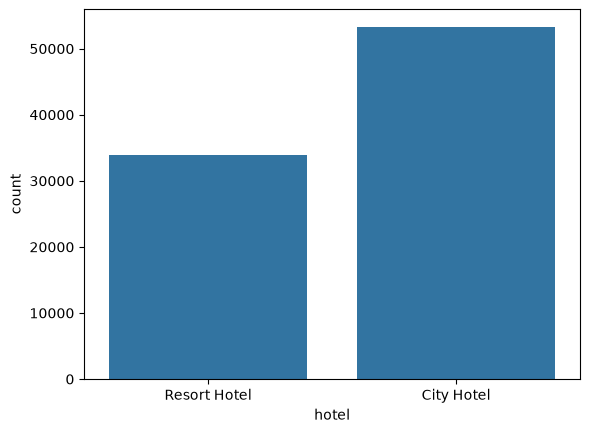

In [363]:
sns.countplot(data = df2 , x = 'hotel')

### 2. Deposit Type Distribution — Deposit Requirements Across Bookings

### 3. Customer Type Distribution — Booking Volume by Guest Type

<Axes: xlabel='deposit_type', ylabel='count'>

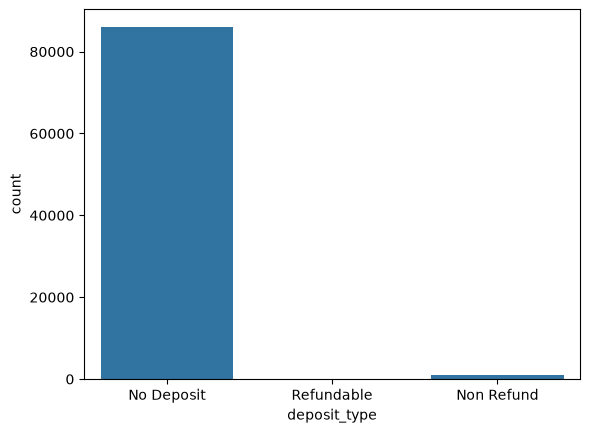

In [364]:
sns.countplot( data = df2, x = 'deposit_type')

<Axes: xlabel='customer_type', ylabel='count'>

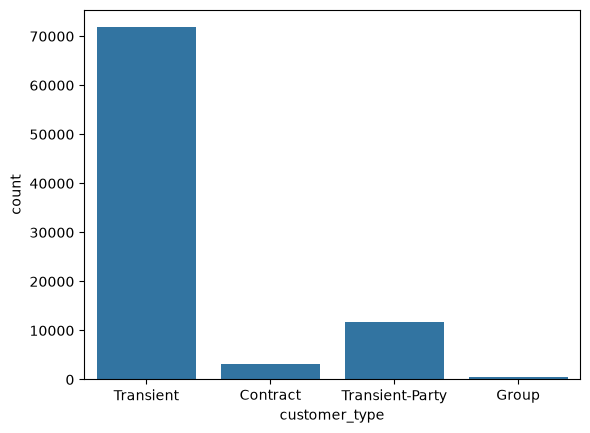

In [365]:
sns.countplot( data = df2 , x='customer_type')

### 4. Overall Cancellation Rate — Cancelled vs. Completed Bookings

In [366]:
df2['is_canceled'].value_counts().sort_index()

is_canceled
0    63158
1    23990
Name: count, dtype: int64

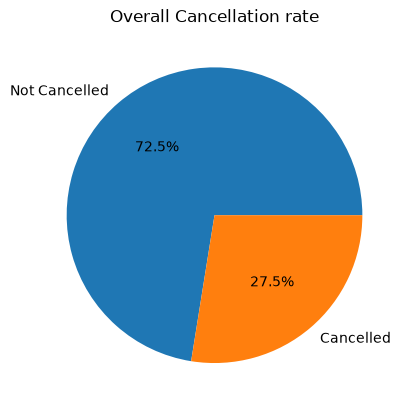

In [367]:
count = df2['is_canceled'].value_counts()
plt.pie(count,labels = ['Not Cancelled','Cancelled'], autopct = "%1.1f%%")
plt.title("Overall Cancellation rate")
plt.show()

### 5. ADR Distribution — Spread of Nightly Room Rates

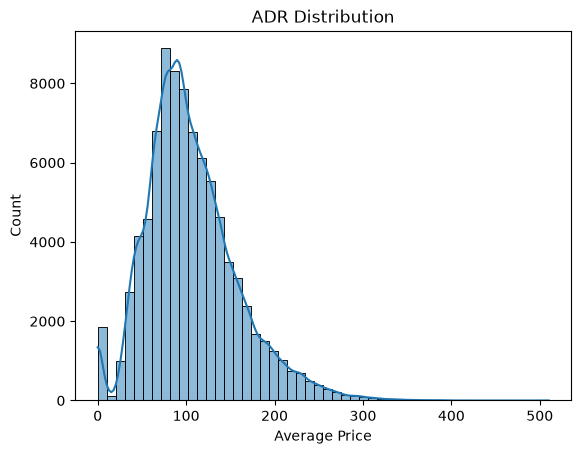

In [368]:
sns.histplot( data = df2, x = 'adr', bins = 50 , kde = True)
plt.title("ADR Distribution")
plt.xlabel("Average Price")
plt.ylabel("Count")
plt.show()

### 6. Lead Time Distribution — How Far in Advance Guests Book

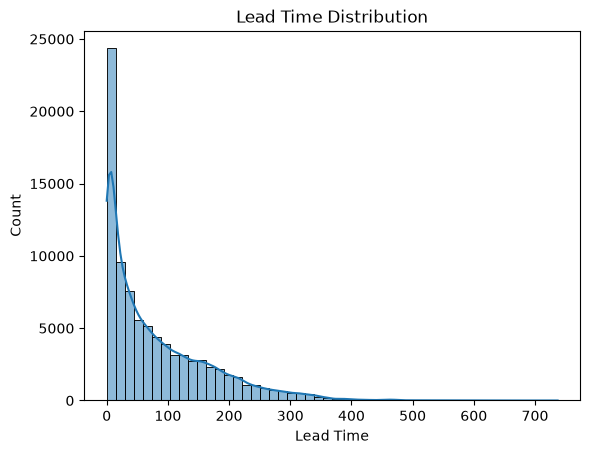

In [369]:
sns.histplot( data = df2, x = 'lead_time' , bins = 50 ,kde = True)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time")
plt.ylabel("Count")
plt.show()

### 7. Length of Stay — Nights Stayed per Booking

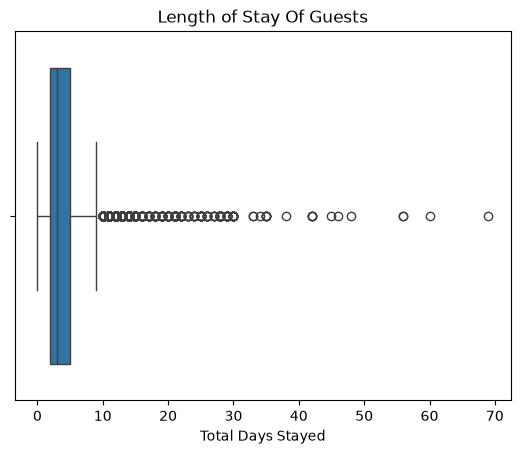

In [370]:
sns.boxplot(data = df2, x = 'total_days_stayed')
plt.title("Length of Stay Of Guests")
plt.xlabel("Total Days Stayed")
plt.show()

### 8. Top 10 Countries by Bookings — Guest Origin by Country

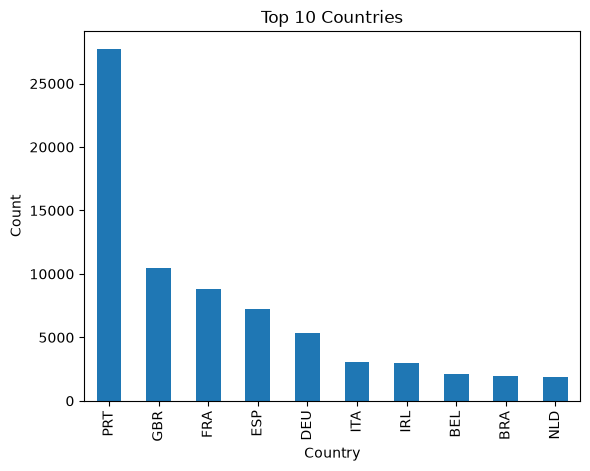

In [371]:
df2['country'].value_counts().head(10).plot(kind = 'bar')
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

## Cancellation for hotels

### 9. City and Resort cancellation gaps

In [372]:
hotel_cancel = round(df2.groupby('hotel')['is_canceled'].mean()* 100,2)
hotel_cancel

hotel
City Hotel      30.10
Resort Hotel    23.48
Name: is_canceled, dtype: float64

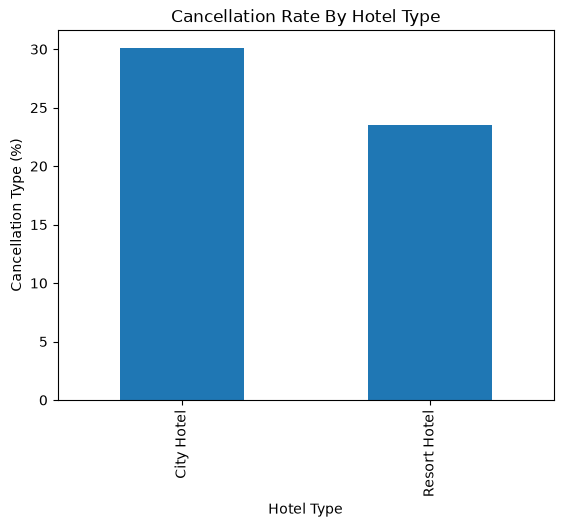

In [373]:
hotel_cancel.plot(kind = 'bar')
plt.title("Cancellation Rate By Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Type (%)")
plt.show()

### 10. Lead Time and the Cancellation Rate

In [374]:
bins = [0,7,30,90,180,366,float('inf')]
labels = ['0-7 days' ,'8-30 days' ,'31-90 days' ,'91-180 days' , '181-366 days' ,'367 and more']
df2['lead_time_group'] = pd.cut(df2['lead_time'],bins= bins ,labels= labels)

In [375]:
lead_cancel = df2.groupby('lead_time_group',observed = True)['is_canceled'].mean() *100

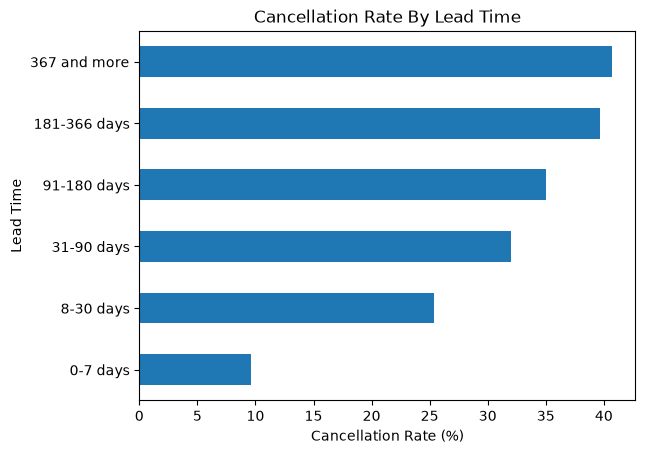

In [376]:
lead_cancel.plot(kind = 'barh')
plt.title("Cancellation Rate By Lead Time")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Lead Time")
plt.show()

### 11. Average Pricing By Season

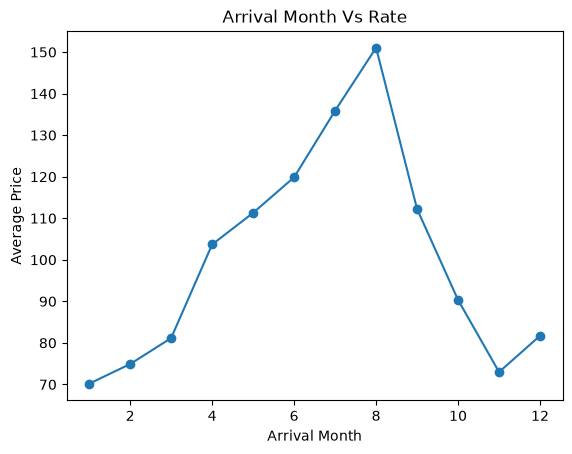

In [377]:
df2['arrival_month'] = df2['arrival_date'].dt.month
df2.groupby('arrival_month')['adr'].mean().plot(kind = 'line',marker = 'o')
plt.title("Arrival Month Vs Rate")
plt.ylabel("Average Price")
plt.xlabel("Arrival Month")
plt.show()

### 12. Room Allocation Differences

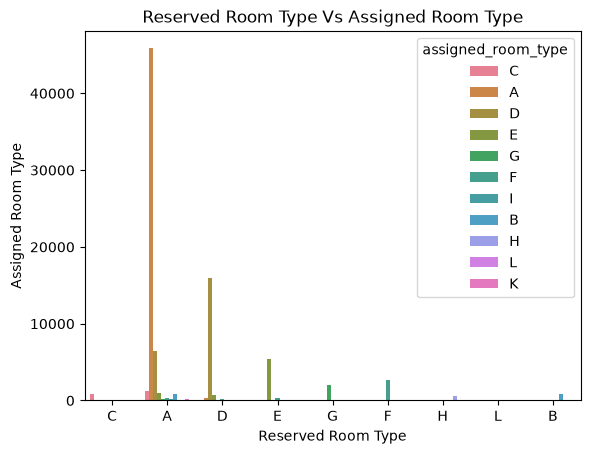

In [378]:
sns.countplot( data = df2 , x = 'reserved_room_type',hue = 'assigned_room_type')
plt.title("Reserved Room Type Vs Assigned Room Type")
plt.xlabel("Reserved Room Type")
plt.ylabel("Assigned Room Type")
plt.show()

## Correlation

<Axes: >

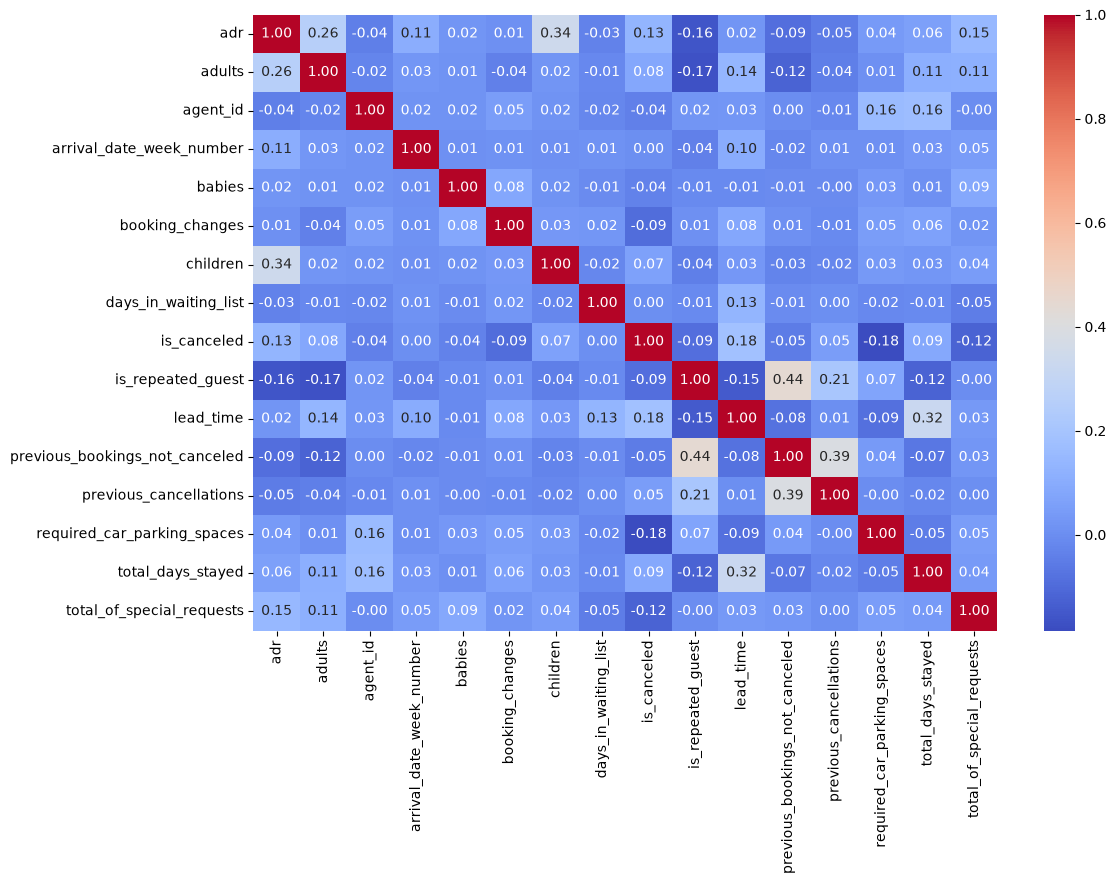

In [379]:
numeric_cols = df2.select_dtypes(include=['int64','float64']).columns.difference(['id'])
plt.figure(figsize=(12,8))
sns.heatmap(df2[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')

All the correlations are weak. This means there is no linear relationship

# lnferences and Conclusion

- Roughly 1 in 4 bookings (27.5%) ends in cancellation, making cancellation the single biggest revenue leak in this dataset.

- City Hotel cancels more often than Resort Hotel (30.1% vs 23.5%), despite also having the higher booking volume.

- Cancellation risk rises sharply with lead time, climbing from ~10% for last-minute bookings to ~40% for those made a year or more in advance.

- Almost all bookings require no deposit, which likely removes any financial disincentive to cancel.

- Transient (individual) travelers dominate the customer base, far outweighing group or contract bookings.

- Room rates follow a clear seasonal curve, peaking in August and bottoming out in November.

- A visible share of guests are assigned a different room type than what they originally reserved, pointing to a real room-allocation gap.

- No single numeric variable strongly correlates with cancellation, showing that cancellations are driven by a mix of moderate factors rather than one dominant cause.
